# Forecasting Baselines: Short-Term Point Forecasts for Estimated WEC Power

This notebook builds simple short-term point-forecasting baselines for the estimated WEC power output prepared in the previous notebooks.

The input data used here is the 30-minute Leixões estimated WEC power time series. The sourcing and sea-state preparation are documented in [wave data preparation](01_wave_data_preparation.ipynb), and the simplified WEC power estimation procedure is documented in [WEC power estimation](02_wec_power_estimation.ipynb).

The main modelling target is `wec_power_norm_estimated`, which represents the estimated WEC power normalized by the nominal 250 kW rating used for the generic WEC proxy. This device-relative scale is useful for modelling because it keeps the target independent of larger rated-power or array-sizing assumptions.

For physical interpretation in plots and reported errors, the normalized target is also shown on the corresponding 250 kW scale:

`wec_power_kw_estimated = wec_power_norm_estimated × 250 kW`

The forecast target is not measured WEC power. It is also not a validated device model, hydrodynamic simulation, or wave-to-wire model. It is a simplified, transparent WEC power proxy derived from observed sea-state variables using the assumptions documented in the WEC power estimation notebook.

The purpose of this notebook is to create reproducible point-forecast baselines and residuals that can support the uncertainty and storage-aware subsequent analyses.

The benchmark uses a compact power-only autoregressive feature set. Wave-height, wave-period, and wave-power-flux variables are not used as predictors in the main benchmark, because the estimated WEC power target was itself constructed from sea-state assumptions. This avoids a forecast model that partly relearns the constructed power-matrix mapping instead of forecasting the estimated power series as a time-dependent signal.

The feature set is intentionally kept small: selected lag values, rolling means, and rolling standard deviations of the estimated power series. This keeps the benchmark interpretable and avoids turning the first forecasting notebook into a broad feature-search exercise.

The forecasting horizons are:

| Horizon | Steps | Operational context |
|---:|---:|---|
| 30 min | 1 | Grid-relevant: next balancing or dispatch interval |
| 1 h | 2 | Grid/storage-relevant: near-term operational planning |
| 2 h | 4 | Storage-relevant: short storage dispatch window |
| 4 h | 8 | Grid/storage-relevant: upper short-term benchmark without external wave forecast inputs |

Missing target values are not imputed. Lag, rolling, and future target values are created only within continuous valid segments of the original 30-minute time axis. This prevents observations separated by data gaps from being treated as adjacent 30-minute observations.

Evaluation uses chronological rolling-origin folds. Each fold contains a training block, a calibration/validation block, and a final test block. Using several rolling-origin test folds gives multiple performance estimates across different time periods, which helps assess the stability of the forecasting baselines rather than relying on a single final split.

The notebook compares a small set of interpretable baseline models:

- Persistence
- Rolling mean
- Ridge regression
- Random forest regression

Performance is reported using MAE, RMSE, and skill scores relative to persistence.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


# Paths
data_path = Path("../data/processed/leixoes_wec_power_30min_estimated.parquet")

output_dir = Path("../outputs/notebook_03")
metrics_path = output_dir / "forecast_metrics.csv"
predictions_path = output_dir / "forecast_predictions.parquet"
folds_path = output_dir / "forecast_folds.csv"


# Target and physical interpretation scale
time_col = "time"
target_col = "wec_power_norm_estimated"
rated_power_kw = 250.0


# Forecast horizons for 30-minute data
horizons = {
    1: {
        "horizon_label": "30 min",
        "horizon_hours": 0.5,
        "operational_context": "Grid-relevant: next balancing or dispatch interval",
    },
    2: {
        "horizon_label": "1 h",
        "horizon_hours": 1.0,
        "operational_context": "Grid/storage-relevant: near-term operational planning",
    },
    4: {
        "horizon_label": "2 h",
        "horizon_hours": 2.0,
        "operational_context": "Storage-relevant: short storage dispatch window",
    },
    8: {
        "horizon_label": "4 h",
        "horizon_hours": 4.0,
        "operational_context": "Grid/storage-relevant: upper short-term benchmark without external wave forecast inputs",
    },
}


# Power-only autoregressive features
lag_steps = [1, 2, 4, 8, 24]
roll_mean_windows = [3, 6, 12]
roll_std_windows = [6, 12]

feature_cols = (
    [f"power_lag_{step}" for step in lag_steps]
    + [f"power_roll_mean_{window}" for window in roll_mean_windows]
    + [f"power_roll_std_{window}" for window in roll_std_windows]
)


# Reproducibility
random_state = 42

## Target availability and continuous segments

Before creating forecasting features, the estimated power target is checked on the original 30-minute time axis.

Missing target values are kept as gaps. Continuous valid segments are identified so that lag, rolling, and future-target features can later be created only within uninterrupted parts of the series.

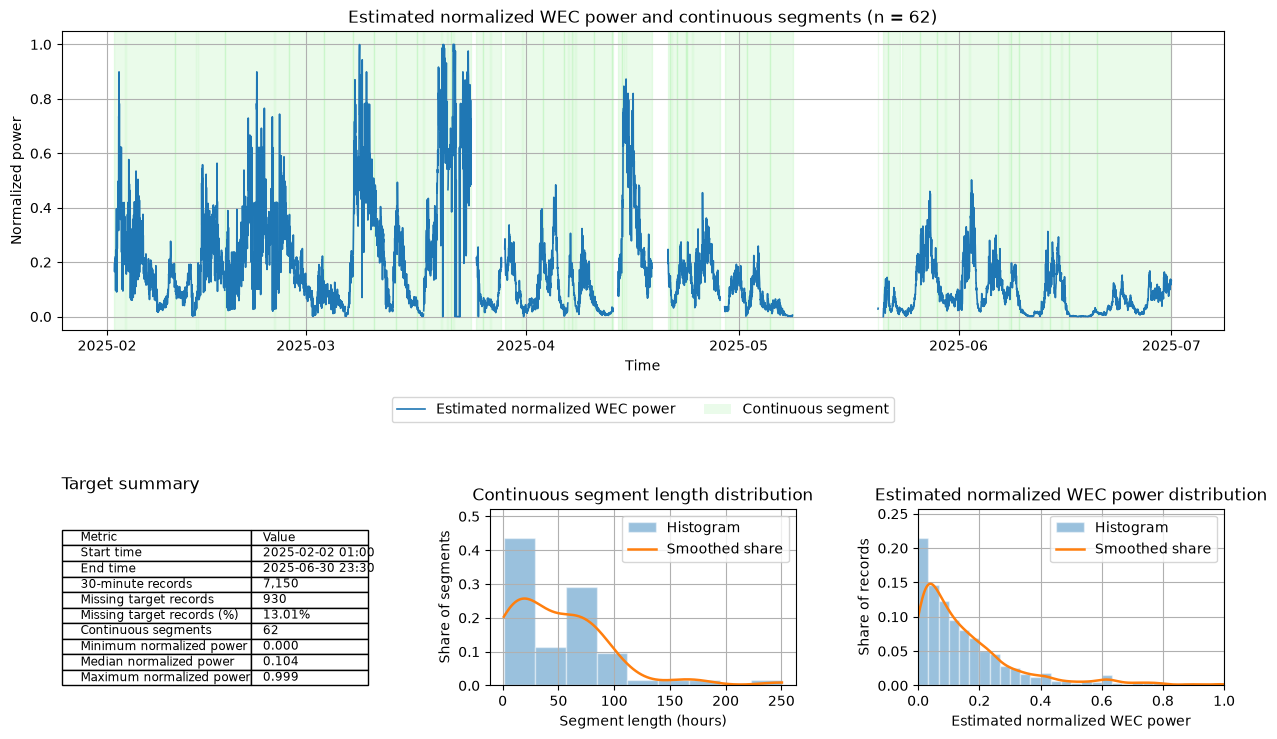

In [8]:
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(data_path).copy()

df[time_col] = pd.to_datetime(df[time_col])
df = df.sort_values(time_col).reset_index(drop=True)

required_cols = [
    time_col,
    "hm0_m",
    "tp_s",
    "te_approx_s",
    "wave_power_flux_kw_m_estimated",
    "wec_power_kw_estimated",
    "wec_power_norm_estimated",
    "high_wave_flag",
    "matrix_input_missing_flag",
    "generic_wec_model_id",
]

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")


# Identify continuous non-missing target segments on the original 30-minute axis
df["target_available"] = df[target_col].notna()

time_step = pd.Timedelta(minutes=30)
time_gap = df[time_col].diff().ne(time_step)
availability_change = df["target_available"].ne(df["target_available"].shift())

df["continuous_segment_id"] = (time_gap | availability_change).cumsum()
df.loc[~df["target_available"], "continuous_segment_id"] = pd.NA

segment_summary = (
    df.loc[df["target_available"]]
    .groupby("continuous_segment_id", dropna=True)
    .agg(
        start_time=(time_col, "min"),
        end_time=(time_col, "max"),
        n_records=(target_col, "size"),
    )
    .reset_index()
)

segment_summary["duration_hours"] = segment_summary["n_records"] * 0.5


# Compact summary table
missing_count = df[target_col].isna().sum()
missing_pct = missing_count / len(df) * 100

summary_table = pd.DataFrame(
    {
        "Metric": [
            "Start time",
            "End time",
            "30-minute records",
            "Missing target records",
            "Missing target records (%)",
            "Continuous segments",
            "Minimum normalized power",
            "Median normalized power",
            "Maximum normalized power",
        ],
        "Value": [
            df[time_col].min().strftime("%Y-%m-%d %H:%M"),
            df[time_col].max().strftime("%Y-%m-%d %H:%M"),
            f"{len(df):,}",
            f"{missing_count:,}",
            f"{missing_pct:.2f}%",
            f"{len(segment_summary):,}",
            f"{df[target_col].min():.3f}",
            f"{df[target_col].median():.3f}",
            f"{df[target_col].max():.3f}",
        ],
    }
)


# Target overview, segment lengths, and target distribution
fig = plt.figure(figsize=(15, 8.5))
gs = fig.add_gridspec(2, 3, height_ratios=[2.2, 1.3], hspace=0.75, wspace=0.4)

ax_ts = fig.add_subplot(gs[0, :])
ax_table = fig.add_subplot(gs[1, 0])
ax_hist_seg = fig.add_subplot(gs[1, 1])
ax_hist_power = fig.add_subplot(gs[1, 2])

for _, row in segment_summary.iterrows():
    ax_ts.axvspan(
        row["start_time"],
        row["end_time"],
        color="lightgreen",
        alpha=0.18,
        zorder=0,
    )

power_line, = ax_ts.plot(
    df[time_col],
    df[target_col],
    linewidth=1.2,
    label="Estimated normalized WEC power",
    zorder=2,
)

segment_patch = Patch(
    facecolor="lightgreen",
    alpha=0.18,
    label="Continuous segment",
)

ax_ts.set_title(
    f"Estimated normalized WEC power and continuous segments (n = {len(segment_summary)})"
)
ax_ts.set_xlabel("Time")
ax_ts.set_ylabel("Normalized power")
ax_ts.legend(
    handles=[power_line, segment_patch],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.20),
    ncol=2,
    frameon=True,
)

ax_table.axis("off")
ax_table.set_title("Target summary", loc="left", pad=14)

table = ax_table.table(
    cellText=summary_table.values,
    colLabels=summary_table.columns,
    cellLoc="left",
    colLoc="left",
    colWidths=[0.62, 0.38],
    bbox=[0, 0, 1, 0.88],
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.15)


# Continuous segment length distribution
segment_lengths = segment_summary["duration_hours"]
segment_bins = np.histogram_bin_edges(segment_lengths, bins="auto")
segment_bin_width = np.diff(segment_bins).mean()
segment_weights = np.ones(len(segment_lengths)) / len(segment_lengths)

seg_hist_values, _, _ = ax_hist_seg.hist(
    segment_lengths,
    bins=segment_bins,
    weights=segment_weights,
    alpha=0.45,
    edgecolor="white",
    label="Histogram",
)

if segment_lengths.nunique() > 1:
    x_grid_seg = np.linspace(segment_lengths.min(), segment_lengths.max(), 300)
    kde_seg = gaussian_kde(segment_lengths)
    kde_seg_share = kde_seg(x_grid_seg) * segment_bin_width

    ax_hist_seg.plot(
        x_grid_seg,
        kde_seg_share,
        linewidth=1.8,
        label="Smoothed share",
    )

    seg_ymax = max(seg_hist_values.max(), kde_seg_share.max()) * 1.2
else:
    seg_ymax = seg_hist_values.max() * 1.2

ax_hist_seg.set_title("Continuous segment length distribution")
ax_hist_seg.set_xlabel("Segment length (hours)")
ax_hist_seg.set_ylabel("Share of segments")
ax_hist_seg.set_ylim(0, min(1, seg_ymax))
ax_hist_seg.legend(frameon=True)


# Estimated normalized WEC power distribution
power_values = df.loc[df[target_col].notna(), target_col]

power_bins = np.linspace(0, 1, 31)
power_bin_width = power_bins[1] - power_bins[0]
power_weights = np.ones(len(power_values)) / len(power_values)

power_hist_values, _, _ = ax_hist_power.hist(
    power_values,
    bins=power_bins,
    weights=power_weights,
    alpha=0.45,
    edgecolor="white",
    label="Histogram",
)

if power_values.nunique() > 1:
    x_grid_power = np.linspace(0, 1, 300)
    kde_power = gaussian_kde(power_values)
    kde_power_share = kde_power(x_grid_power) * power_bin_width

    ax_hist_power.plot(
        x_grid_power,
        kde_power_share,
        linewidth=1.8,
        label="Smoothed share",
    )

    power_ymax = max(power_hist_values.max(), kde_power_share.max()) * 1.2
else:
    power_ymax = power_hist_values.max() * 1.2

ax_hist_power.set_title("Estimated normalized WEC power distribution")
ax_hist_power.set_xlabel("Estimated normalized WEC power")
ax_hist_power.set_ylabel("Share of records")
ax_hist_power.set_xlim(0, 1)
ax_hist_power.set_ylim(0, min(1, power_ymax))
ax_hist_power.legend(frameon=True)

plt.show()

The target series contains 62 continuous non-missing segments, with about 13% missing target records on the original 30-minute time axis. Estimated normalized WEC power is concentrated at low-to-moderate output levels, with fewer near-rated values.

The following forecasting features are therefore created within each continuous segment only, so lagged and rolling predictors do not cross missing-data gaps.